# 05 — Training Loop

Quinto notebook del pipeline tracked. Entrena el modelo `PHNModel` (HPN + GraphSAGE,
definido en `04_model.ipynb`) sobre el dataset de `03_preference_matching.ipynb`,
con supervisión por **dynamic matching**.

Para cada muestra del batch:
1. Se muestrea `r = (r_cov, r_cost)` del símplex
2. Dynamic matching entrega `y*(r)` del frente de Pareto
3. El modelo predice `p̂ = σ(GNN(grafo; HPN(r)))` — probabilidad por nodo
4. Pérdida: BCE ponderada por clase entre `p̂` e `y*`

**Pérdida ponderada**: para cada batch se calcula el ratio negativo/positivo
y se penaliza los falsos negativos más que los falsos positivos,
compensando la fuerte asimetría (pocas cámaras = pocos nodos positivos).

In [ ]:
import sys, json, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.nn import MessagePassing
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

ROOT       = Path("..")
GRAPH_DIR  = ROOT / "data" / "graphs"
PARETO_DIR = ROOT / "data" / "baselines" / "clean"
CKPT_DIR   = ROOT / "checkpoints_VF"
CKPT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cpu")
print(f"device : {DEVICE}")

with open(GRAPH_DIR / "split.json") as f:
    split = json.load(f)
print(f"train  : {len(split['train'])}  instancias")
print(f"val    : {len(split['val'])}   instancias")

## Clases del pipeline (nb03 + nb04)

In [22]:
# ── ParetoDataset ─────────────────────────────────────────────────────────────
class ParetoDataset(Dataset):
    def __init__(self, instance_names, graph_dir, pareto_dir, n_pref=1, seed=None):
        super().__init__()
        self.n_pref = n_pref
        self.rng    = np.random.default_rng(seed)
        self.instances = []
        missing = []
        for name in instance_names:
            g = Path(graph_dir) / (name + ".pt")
            o = Path(pareto_dir) / name / "objectives.npy"
            s = Path(pareto_dir) / name / "solutions.npy"
            if not g.exists() or not o.exists():
                missing.append(name); continue
            graph = torch.load(g, weights_only=False)
            self.instances.append({
                "name": name, "graph": graph,
                "objectives": np.load(o), "solutions": np.load(s),
            })
        if missing:
            print(f"WARNING: {len(missing)} instancias no encontradas")

    def __len__(self):  return len(self.instances) * self.n_pref

    def __getitem__(self, idx):
        inst  = self.instances[idx % len(self.instances)]
        graph = inst["graph"]
        r     = self._sample_r()
        y_star = self._dynamic_match(inst["objectives"], inst["solutions"], r, graph)
        data = Data(x=graph.x, edge_index=graph.edge_index)
        data.instance_name = graph.instance_name
        data.n_candidates  = graph.n_candidates
        data.cov_max       = graph.cov_max
        data.r      = torch.tensor(r,      dtype=torch.float)
        data.y_star = torch.tensor(y_star, dtype=torch.float)
        return data

    def _sample_r(self):
        r1 = self.rng.uniform(0.0, 1.0)
        return np.array([r1, 1.0 - r1], dtype=np.float32)

    def _dynamic_match(self, objectives, solutions, r, graph):
        cov  = -objectives[:, 0]
        cost =  objectives[:, 1]
        scores = r[0] * (1 - cov / graph.cov_max) + r[1] * (cost / graph.n_candidates)
        return solutions[int(np.argmin(scores))].astype(np.float32)

In [23]:
# ── Arquitectura PHN + GraphSAGE ──────────────────────────────────────────────
class MeanAggregator(MessagePassing):
    def __init__(self):            super().__init__(aggr='mean')
    def forward(self, x, ei, N):  return self.propagate(ei, x=x, size=(N, N))
    def message(self, x_j):       return x_j


class HyperNetwork(nn.Module):
    def __init__(self, ray_hidden=100, gnn_hidden=64, in_channels=3):
        super().__init__()
        self.gnn_hidden = gnn_hidden; self.in_channels = in_channels
        h, c = gnn_hidden, in_channels
        self.ray_mlp = nn.Sequential(
            nn.Linear(2, ray_hidden), nn.ReLU(),
            nn.Linear(ray_hidden, ray_hidden), nn.ReLU(),
        )
        self.c1_ll_w = nn.Linear(ray_hidden, h * c)
        self.c1_ll_b = nn.Linear(ray_hidden, h)
        self.c1_lr_w = nn.Linear(ray_hidden, h * c)
        self.c2_ll_w = nn.Linear(ray_hidden, h * h)
        self.c2_ll_b = nn.Linear(ray_hidden, h)
        self.c2_lr_w = nn.Linear(ray_hidden, h * h)
        self.fin_w   = nn.Linear(ray_hidden, h)
        self.fin_b   = nn.Linear(ray_hidden, 1)

    def forward(self, r):
        feat = self.ray_mlp(r)
        h, c, B = self.gnn_hidden, self.in_channels, r.size(0)
        return {
            'c1_ll_w': self.c1_ll_w(feat).view(B, h, c),
            'c1_ll_b': self.c1_ll_b(feat),
            'c1_lr_w': self.c1_lr_w(feat).view(B, h, c),
            'c2_ll_w': self.c2_ll_w(feat).view(B, h, h),
            'c2_ll_b': self.c2_ll_b(feat),
            'c2_lr_w': self.c2_lr_w(feat).view(B, h, h),
            'fin_w':   self.fin_w(feat).view(B, 1, h),
            'fin_b':   self.fin_b(feat).view(B, 1),
        }


class PHNGraphSAGE(nn.Module):
    def __init__(self, hidden=64, dropout=0.4):
        super().__init__()
        self.agg     = MeanAggregator()
        self.bn1     = nn.BatchNorm1d(hidden)
        self.bn2     = nn.BatchNorm1d(hidden)
        self.dropout = dropout

    def _sage(self, x, ei, ll_w, ll_b, lr_w, N):
        agg = self.agg(x, ei, N)
        return F.linear(agg, ll_w, ll_b) + F.linear(x, lr_w)

    def forward(self, x, ei, w):
        N = x.size(0)
        h = self._sage(x, ei, w['c1_ll_w'], w['c1_ll_b'], w['c1_lr_w'], N)
        h = F.relu(self.bn1(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self._sage(h, ei, w['c2_ll_w'], w['c2_ll_b'], w['c2_lr_w'], N)
        h = F.relu(self.bn2(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return torch.sigmoid(F.linear(h, w['fin_w'], w['fin_b'])).squeeze(-1)


class PHNModel(nn.Module):
    def __init__(self, in_channels=3, gnn_hidden=64, ray_hidden=100, dropout=0.4):
        super().__init__()
        self.hnet = HyperNetwork(ray_hidden, gnn_hidden, in_channels)
        self.gnn  = PHNGraphSAGE(gnn_hidden, dropout)

    def forward(self, batch):
        r = batch.r.view(batch.num_graphs, 2)
        b = batch.batch
        weights = self.hnet(r)
        outputs, offset = [], 0
        for i in range(batch.num_graphs):
            mask = (b == i)
            x_i  = batch.x[mask]
            N_i  = x_i.size(0)
            e_m  = mask[batch.edge_index[0]]
            ei_i = batch.edge_index[:, e_m] - offset
            w_i  = {k: v[i] for k, v in weights.items()}
            outputs.append(self.gnn(x_i, ei_i, w_i))
            offset += N_i
        return torch.cat(outputs)

    def n_params(self):
        return sum(p.numel() for p in self.parameters())

## Hiperparámetros

In [ ]:
# ── Modelo ────────────────────────────────────────────────────────────────────
IN_CHANNELS = 3     # [flag, prob, degree]
GNN_HIDDEN  = 64
RAY_HIDDEN  = 100
DROPOUT     = 0.5

# ── Entrenamiento ─────────────────────────────────────────────────────────────
N_PREF_TRAIN = 25   # preferencias por instancia por época → 1500 muestras
N_PREF_VAL   = 25    # preferencias por instancia en val   → 125 muestras
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 5e-4
N_EPOCHS     = 50
PATIENCE     = 20   # early stopping

# ── Archivos de salida ────────────────────────────────────────────────────────
CKPT_BEST    = CKPT_DIR / "best_model.pt"
CKPT_LAST    = CKPT_DIR / "last_model.pt"
HISTORY_FILE = CKPT_DIR / "history.json"

print(f"Muestras train/época : {len(split['train']) * N_PREF_TRAIN}")
print(f"Muestras val/época   : {len(split['val'])   * N_PREF_VAL}")
print(f"Batches train/época  : {len(split['train']) * N_PREF_TRAIN // BATCH_SIZE}")

Muestras train/época : 16000
Muestras val/época   : 4000
Batches train/época  : 500


## Función de pérdida

BCE ponderada por clase: para cada batch se calcula el ratio negativo/positivo
y los nodos con `y=1` (cámaras instaladas) reciben un peso proporcional a ese ratio.
Así los errores en la clase minoritaria pesan igual que los de la mayoritaria.

In [25]:
def weighted_bce(probs: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    BCE con ponderación dinámica por clase.
    Los nodos con y=1 reciben peso = n_neg / n_pos;
    los nodos con y=0 reciben peso = 1.
    Equivalente a BCEWithLogitsLoss(pos_weight=...) pero sobre probabilidades.
    """
    n_pos = y.sum().clamp(min=1.0)
    n_neg = (y.numel() - y.sum()).clamp(min=1.0)
    w = torch.where(y.bool(),
                    (n_neg / n_pos) * torch.ones_like(y),
                    torch.ones_like(y))
    return F.binary_cross_entropy(probs.clamp(1e-6, 1 - 1e-6), y, weight=w)


# Verificación: con predicción perfecta la pérdida debe ser ~0
y_test = torch.tensor([1., 1., 0., 0., 0., 0., 0., 0.])
p_perf = y_test.clone().clamp(1e-6, 1 - 1e-6)
p_rand = torch.rand_like(y_test)
print(f"BCE ponderada — perfecta: {weighted_bce(p_perf, y_test):.6f}")
print(f"BCE ponderada — random  : {weighted_bce(p_rand, y_test):.4f}")

BCE ponderada — perfecta: 0.000002
BCE ponderada — random  : 1.5340


## DataLoaders

In [26]:
ds_train = ParetoDataset(split["train"], GRAPH_DIR, PARETO_DIR,
                         n_pref=N_PREF_TRAIN, seed=42)
ds_val   = ParetoDataset(split["val"],   GRAPH_DIR, PARETO_DIR,
                         n_pref=N_PREF_VAL,   seed=0)

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train loader: {len(loader_train)} batches/época")
print(f"Val   loader: {len(loader_val)}  batches/época")

Train loader: 500 batches/época
Val   loader: 125  batches/época


## Inicializar modelo, optimizador y scheduler

In [ ]:
torch.manual_seed(42)

model = PHNModel(
    in_channels=IN_CHANNELS,
    gnn_hidden=GNN_HIDDEN,
    ray_hidden=RAY_HIDDEN,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Reduce LR a la mitad cuando val_loss no mejora en 10 épocas consecutivas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

print(f"Parámetros totales: {model.n_params():,}")

Parámetros totales: 1,959,781


## Funciones train / eval por época

In [28]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        probs = model(batch)
        loss  = weighted_bce(probs, batch.y_star)
        loss.backward()
        # Clip de gradientes para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    total_tp = total_fp = total_fn = 0

    for batch in loader:
        batch = batch.to(DEVICE)
        probs = model(batch)
        y     = batch.y_star

        total_loss += weighted_bce(probs, y).item()

        # Métricas binarias con umbral 0.5
        preds = (probs >= 0.5).float()
        total_tp += ((preds == 1) & (y == 1)).sum().item()
        total_fp += ((preds == 1) & (y == 0)).sum().item()
        total_fn += ((preds == 0) & (y == 1)).sum().item()

    avg_loss = total_loss / len(loader)
    precision = total_tp / max(total_tp + total_fp, 1)
    recall    = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    return avg_loss, precision, recall, f1

## Loop de entrenamiento

In [29]:
history = {"train_loss": [], "val_loss": [], "val_f1": [], "lr": []}

best_val_f1    =  -1.0
epochs_no_improve = 0
t0               = time.time()

epoch_bar = tqdm(range(1, N_EPOCHS + 1), desc="Épocas")

for epoch in epoch_bar:

    train_loss             = train_epoch(model, loader_train, optimizer)
    val_loss, prec, rec, f1 = eval_epoch(model, loader_val)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(f1)
    history["lr"].append(current_lr)

    # Guardar mejor modelo
    if f1 > best_val_f1:
        best_val_f1 = f1
        epochs_no_improve = 0
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "val_loss":   val_loss,
            "val_f1":     f1,
            "config": {
                "in_channels": IN_CHANNELS,
                "gnn_hidden":  GNN_HIDDEN,
                "ray_hidden":  RAY_HIDDEN,
                "dropout":     DROPOUT,
            }
        }, CKPT_BEST)
        marker = " ★"
    else:
        epochs_no_improve += 1
        marker = ""

    epoch_bar.set_postfix({
        "tr": f"{train_loss:.4f}",
        "val": f"{val_loss:.4f}",
        "f1": f"{f1:.3f}",
        "lr": f"{current_lr:.2e}",
    })

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(
            f"Época {epoch:4d}/{N_EPOCHS} "
            f"| train={train_loss:.4f} "
            f"| val={val_loss:.4f} "
            f"| P={prec:.3f} R={rec:.3f} F1={f1:.3f} "
            f"| lr={current_lr:.2e} "
            f"| t={elapsed:.0f}s{marker}"
        )

    # Early stopping
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping en época {epoch} (sin mejora en {PATIENCE} épocas)")
        break

# Guardar último modelo e historial
torch.save(model.state_dict(), CKPT_LAST)
with open(HISTORY_FILE, "w") as f:
    json.dump(history, f, indent=2)

total_time = time.time() - t0
print(f"\nEntrenamiento terminado en {total_time/60:.1f} min")
print(f"Mejor val_f1: {best_val_f1:.4f} → guardado en {CKPT_BEST}")

Épocas:   0%|          | 0/25 [00:00<?, ?it/s]

Época    1/25 | train=0.4940 | val=0.5478 | P=0.570 R=0.819 F1=0.673 | lr=1.00e-03 | t=133s ★
Época   10/25 | train=0.4268 | val=0.6143 | P=0.701 R=0.749 F1=0.725 | lr=5.00e-04 | t=1745s
Época   20/25 | train=0.4235 | val=0.5261 | P=0.543 R=0.845 F1=0.661 | lr=2.50e-04 | t=3123s

Entrenamiento terminado en 62.8 min
Mejor val_f1: 0.7453 → guardado en ..\checkpoints_train_v1_96\best_model.pt


## Curvas de entrenamiento

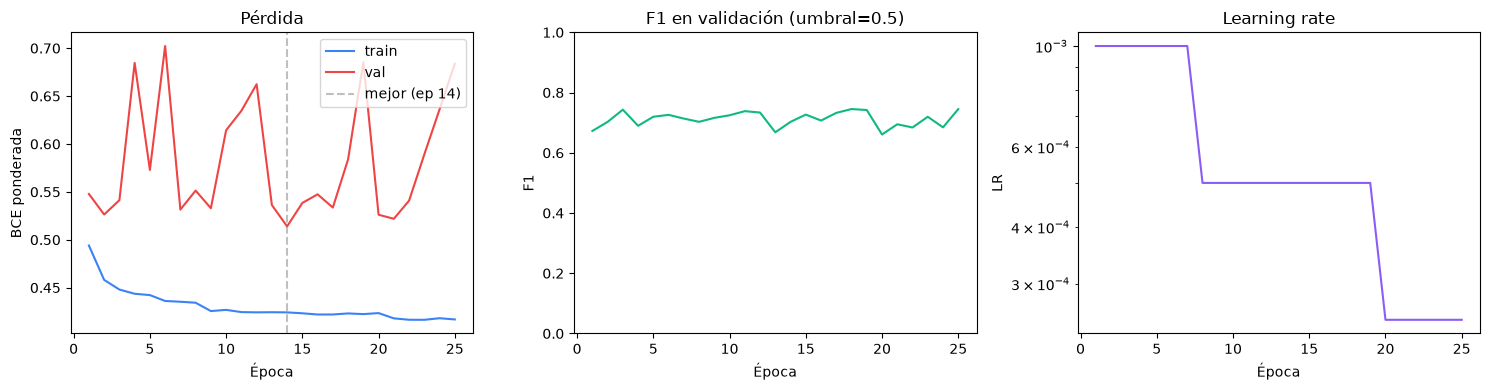

Curvas guardadas en ..\checkpoints_train_v1_96\training_curves.png


In [30]:
epochs_done = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pérdida
axes[0].plot(epochs_done, history["train_loss"], label="train", color="#3B82F6")
axes[0].plot(epochs_done, history["val_loss"],   label="val",   color="#EF4444")
best_ep = int(np.argmin(history["val_loss"])) + 1
axes[0].axvline(best_ep, color="gray", linestyle="--", alpha=0.5, label=f"mejor (ep {best_ep})")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("BCE ponderada")
axes[0].set_title("Pérdida"); axes[0].legend()

# F1
axes[1].plot(epochs_done, history["val_f1"], color="#10B981")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("F1")
axes[1].set_title("F1 en validación (umbral=0.5)")
axes[1].set_ylim(0, 1)

# Learning rate
axes[2].plot(epochs_done, history["lr"], color="#8B5CF6")
axes[2].set_xlabel("Época"); axes[2].set_ylabel("LR")
axes[2].set_title("Learning rate")
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Curvas guardadas en {CKPT_DIR / 'training_curves.png'}")

## Verificación post-entrenamiento

Cargamos el mejor modelo y verificamos que genera soluciones distintas para distintos r.

In [32]:
# Cargar mejor checkpoint
ckpt = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=False)
cfg  = ckpt["config"]
best_model = PHNModel(**cfg).to(DEVICE)
best_model.load_state_dict(ckpt["model"])
best_model.eval()

print(f"Mejor modelo — época {ckpt['epoch']} | val_loss={ckpt['val_loss']:.4f} | F1={ckpt['val_f1']:.3f}")
print()

# Tomar una instancia de validación y probar con varios r
sample = ds_val[0]
inst   = ds_val.instances[0]
print(f"Instancia: {sample.instance_name}")
print(f"N_total: {sample.x.shape[0]}  |  n_pareto: {inst['graph'].n_pareto}")
print()

r_test = [
    ("solo cobertura",  1.0, 0.0),
    ("equilibrado",     0.5, 0.5),
    ("solo costo",      0.0, 1.0),
]

print(f"{'r':>25}  {'cámaras predichas (p>0.5)':>26}  {'cámaras reales (y*)':>20}")

for label, r_cov, r_cost in r_test:
    r = np.array([r_cov, r_cost], dtype=np.float32)

    # Construir muestra con este r específico
    y_star = ds_val._dynamic_match(inst["objectives"], inst["solutions"], r, inst["graph"])

    data = Data(x=sample.x, edge_index=sample.edge_index)
    data.r      = torch.tensor(r)
    data.y_star = torch.tensor(y_star)
    data.instance_name = sample.instance_name
    data.n_candidates  = sample.n_candidates
    data.cov_max       = sample.cov_max

    from torch_geometric.data import Batch
    batch_single = Batch.from_data_list([data]).to(DEVICE)

    with torch.no_grad():
        probs = best_model(batch_single)

    n_pred = (probs >= 0.5).sum().item()
    n_real = int(y_star.sum())
    print(f"  r=({r_cov:.1f},{r_cost:.1f}) {label:>18}  →  pred={n_pred:4d}  real={n_real:4d}")

Mejor modelo — época 18 | val_loss=0.5840 | F1=0.745

Instancia: wsc_604_R0p0848_pre11
N_total: 150  |  n_pareto: 30

                        r   cámaras predichas (p>0.5)   cámaras reales (y*)
  r=(1.0,0.0)     solo cobertura  →  pred=  35  real=  47
  r=(0.5,0.5)        equilibrado  →  pred=  46  real=  37
  r=(0.0,1.0)         solo costo  →  pred=  11  real=  11


## Resumen de archivos generados

Todo se guarda en `CKPT_DIR` (por defecto `checkpoints_VF/`):

| Archivo | Contenido |
|---|---|
| `best_model.pt` | `state_dict` + config + val_loss del mejor epoch |
| `last_model.pt` | `state_dict` del último epoch |
| `history.json` | `train_loss`, `val_loss`, `val_f1`, `lr` por época |
| `training_curves.png` | Gráficas de pérdida, F1 y LR |